In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-11.parquet')

In [2]:
df.shape

(4181444, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1951134,2,2025-11-18 16:45:53,2025-11-18 17:52:01,1.0,23.12,4.0,N,132,265,1,140.2,2.5,0.5,28.84,0.0,1.0,174.79,0.0,1.75,0.0
2601475,2,2025-11-24 14:35:55,2025-11-24 14:51:21,1.0,1.35,1.0,N,140,236,1,14.2,0.0,0.5,3.64,0.0,1.0,21.84,2.5,0.00,0.0
2458186,2,2025-11-22 22:50:46,2025-11-22 22:54:44,1.0,0.72,1.0,N,263,43,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.00,0.0


In [4]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1014740
trip_distance                  0
RatecodeID               1014740
store_and_fwd_flag       1014740
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1014740
Airport_fee              1014740
cbd_congestion_fee             0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-11-01') | (df["tpep_pickup_datetime"] >= '2025-12-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,7,2025-11-01 00:13:25,2025-11-01 00:13:25,1.0,1.68,1.0,N,43,186,1,14.90,0.0,0.5,1.50,0.0,1.0,22.15,2.5,0.0,0.75
21,7,2025-11-01 00:09:20,2025-11-01 00:09:20,1.0,1.29,1.0,N,79,125,1,12.80,0.0,0.5,3.71,0.0,1.0,22.26,2.5,0.0,0.75
22,7,2025-11-01 00:38:59,2025-11-01 00:38:59,1.0,1.66,1.0,N,158,79,1,21.20,0.0,0.5,5.39,0.0,1.0,32.34,2.5,0.0,0.75
23,7,2025-11-01 00:55:33,2025-11-01 00:55:33,1.0,1.25,1.0,N,79,90,1,13.50,0.0,0.5,3.00,0.0,1.0,22.25,2.5,0.0,0.75
30,7,2025-11-01 00:14:12,2025-11-01 00:14:12,1.0,2.89,1.0,N,50,263,1,16.30,0.0,0.5,4.41,0.0,1.0,26.46,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3913722,2,2025-11-22 10:02:00,2025-11-22 10:02:00,NaN,0.08,NaN,None,230,230,0,11.68,0.0,0.5,3.67,0.0,1.0,20.10,NaN,NaN,0.75
3979407,2,2025-11-24 02:39:00,2025-11-24 02:39:00,NaN,0.01,NaN,None,36,36,0,0.61,0.0,0.5,0.00,0.0,1.0,2.11,NaN,NaN,0.00
4030217,2,2025-11-25 20:23:00,2025-11-25 20:23:00,NaN,0.01,NaN,None,141,141,0,-3.99,0.0,0.5,0.00,0.0,1.0,5.01,NaN,NaN,0.00
4062269,2,2025-11-26 20:06:00,2025-11-26 20:06:00,NaN,0.10,NaN,None,42,41,0,27.94,0.0,0.5,0.00,0.0,1.0,29.44,NaN,NaN,0.00


In [8]:
# проблемных строк 60862
# 60862 записей составляют ~1.45% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [9]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [10]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
473,1,2025-11-01 00:31:02,2025-11-01 01:08:01,3.0,1.40,1.0,N,264,90,1,28.90,4.25,0.5,6.90,0.00,1.0,41.55,2.5,0.0,0.75
914,2,2025-11-01 00:59:19,2025-11-01 01:06:58,1.0,1.38,1.0,N,264,229,1,10.00,1.00,0.5,3.15,0.00,1.0,18.90,2.5,0.0,0.75
1108,1,2025-11-01 00:07:24,2025-11-01 00:12:41,1.0,1.00,1.0,N,264,75,2,7.90,3.50,0.5,0.00,0.00,1.0,12.90,2.5,0.0,0.00
1109,1,2025-11-01 00:26:58,2025-11-01 01:11:37,2.0,6.90,1.0,N,264,264,1,41.50,4.25,0.5,4.00,0.00,1.0,51.25,2.5,0.0,0.75
1498,1,2025-11-01 00:45:19,2025-11-01 01:02:05,1.0,2.00,1.0,N,264,143,1,16.30,4.25,0.5,3.31,0.00,1.0,25.36,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4141647,2,2025-11-29 17:13:36,2025-11-29 17:47:22,NaN,9.74,NaN,None,264,264,0,1.32,0.00,0.5,0.00,0.00,1.0,2.82,NaN,NaN,0.00
4158630,2,2025-11-30 04:48:43,2025-11-30 05:32:34,NaN,30.03,NaN,None,264,264,0,71.28,0.00,0.5,20.00,0.00,1.0,92.78,NaN,NaN,0.00
4159790,2,2025-11-30 06:27:48,2025-11-30 06:49:26,NaN,0.00,NaN,None,264,264,0,25.12,0.00,0.5,0.00,0.00,1.0,29.12,NaN,NaN,0.00
4160375,1,2025-11-30 07:54:53,2025-11-30 08:15:30,NaN,8.40,NaN,None,264,42,0,35.90,0.00,0.5,4.43,6.94,1.0,48.77,NaN,NaN,0.00


In [11]:
# записей с зоной 264 всего 6133
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [12]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4181444-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 66995
осталось записей о поездке: 4114449
максимальная и минимальная даты в таблице: 2025-11-30 23:59:59 2025-11-01 00:00:00


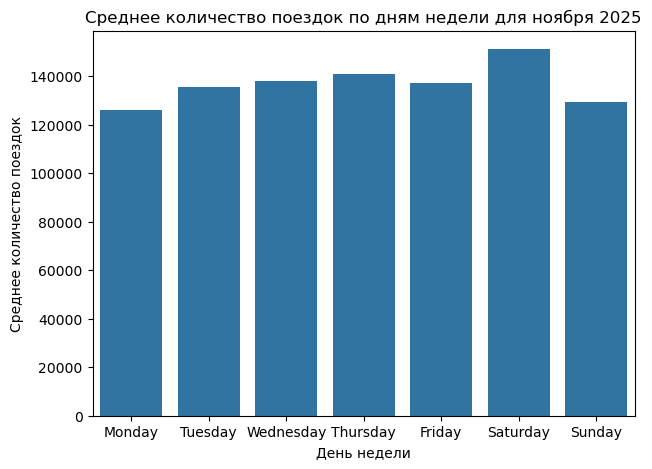

In [13]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для ноября 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

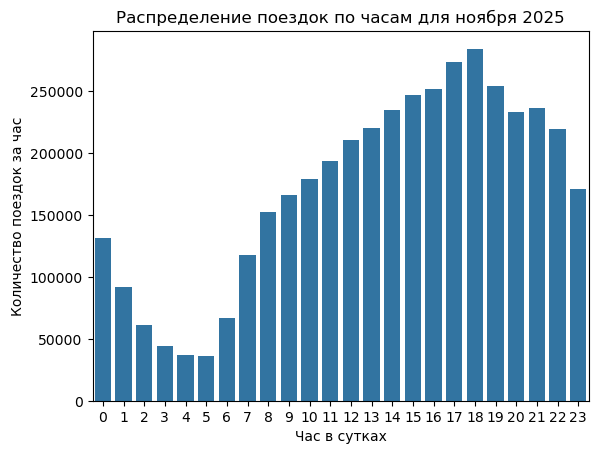

In [23]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для ноября 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

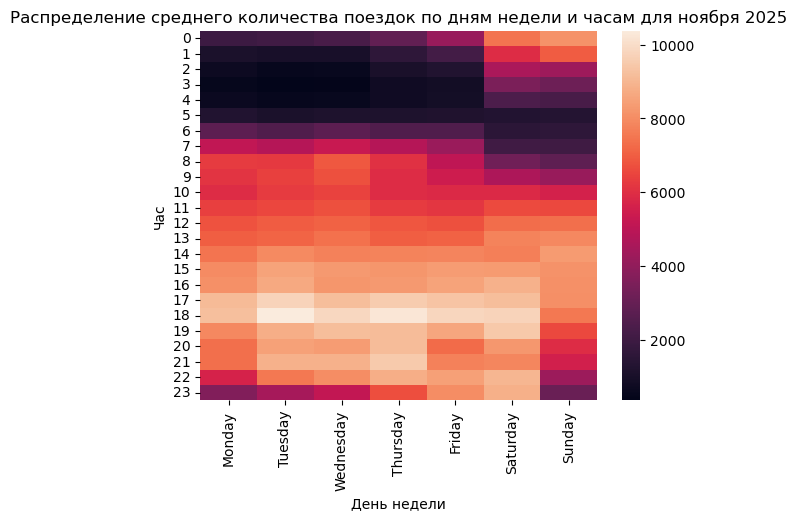

In [15]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для ноября 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [16]:
# Графики распределений не имеют значимых отличий от октябрьских,
# пик активности тут приходится на вторник 18 ч.

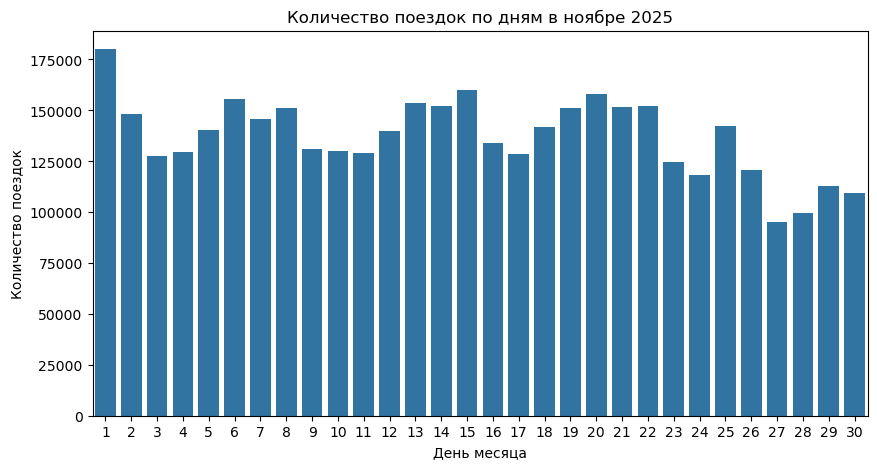

In [24]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в ноябре 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Недельная цикличность сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 3, 10, 17, 24 ноября.
# В четвёртый четверг ноября в США отмечают День благодарения, то есть в 2025 году это было 27 ноября.
# Празднование, чаще в семейном кругу, длится несколько дней вплоть до конца выходных, то есть до 30 ноября,
# именно это объясняет падение количества поездок с 27 по 30 число.

In [18]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,392
EWR,592
Bronx,34872
Brooklyn,154688
Queens,371276
Manhattan,3550739


In [19]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-11-01,0,79,537
1,2025-11-01,0,161,163
2,2025-11-01,0,163,131
3,2025-11-01,0,186,200
4,2025-11-01,0,239,181
...,...,...,...,...
3593,2025-11-30,23,79,65
3594,2025-11-30,23,161,50
3595,2025-11-30,23,163,48
3596,2025-11-30,23,186,109


In [20]:
# В таблице должно быть 30 дней x 24 часа x 5 зон = 3600 записей, сейчас в таблице 3598 записей.

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-11-01", "2025-11-30", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-11-01,0,79,537
1,2025-11-01,0,161,163
2,2025-11-01,0,163,131
3,2025-11-01,0,186,200
4,2025-11-01,0,239,181
...,...,...,...,...
3595,2025-11-30,23,79,65
3596,2025-11-30,23,161,50
3597,2025-11-30,23,163,48
3598,2025-11-30,23,186,109


In [21]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_11.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [22]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3600, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
